# Data Drift Detection System

## Objective
Detect distribution shifts between training and production datasets using statistical testing.

## Techniques Used
- Pandas
- SciPy KS Test
- Matplotlib
- Seaborn
- Drift Severity Scoring

## Features
- Automated Drift Detection
- Severity Analysis
- Visualization Dashboard
- Retraining Recommendation Engine

# Data Drift Detection System

## Overview
This project detects distributional shifts between training and production datasets using statistical testing and monitors the impact of drift on machine learning model performance.

## Objectives
- Detect feature-level drift using the Kolmogorov-Smirnov (KS) Test
- Measure drift severity
- Visualize distribution shifts
- Monitor model performance degradation
- Generate retraining recommendations

## Technologies
- Python
- Pandas
- NumPy
- SciPy
- Scikit-learn
- Matplotlib
- Seaborn

## Workflow

Training Data
→ Train Random Forest Model
→ Simulate Production Data
→ Detect Drift
→ Measure Accuracy Drop
→ Generate Drift Report
→ Recommend Retraining

In [1]:
print("Notebook working!")

Notebook working!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ks_2samp

print("Libraries loaded successfully")

Matplotlib is building the font cache; this may take a moment.


Libraries loaded successfully


In [3]:
cols = [
    "age","workclass","fnlwgt","education",
    "education_num","marital_status",
    "occupation","relationship","race",
    "sex","capital_gain","capital_loss",
    "hours_per_week","native_country",
    "income"
]

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

df = pd.read_csv(url, names=cols)

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [4]:
print(df.shape)

(32561, 15)


In [5]:
df.to_csv("../data/train.csv", index=False)

print("train.csv created successfully")

train.csv created successfully


In [6]:
train = pd.read_csv("../data/train.csv")

production = train.copy()

production["age"] += 10

production["hours_per_week"] += 5

production["capital_gain"] = production["capital_gain"] * 1.2

production.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,49,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2608.8,0,45,United-States,<=50K
1,60,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0,18,United-States,<=50K
2,48,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0,45,United-States,<=50K
3,63,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0,45,United-States,<=50K
4,38,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0,45,Cuba,<=50K


In [7]:
production.to_csv("../data/production.csv", index=False)

print("production.csv created successfully")

production.csv created successfully


In [8]:
numeric_cols = train.select_dtypes(include="number").columns

print(numeric_cols)

Index(['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss',
       'hours_per_week'],
      dtype='str')


In [9]:
results = []

In [10]:
for col in numeric_cols:

    stat, p = ks_2samp(
        train[col],
        production[col]
    )

    drift = "Yes" if p < 0.05 else "No"

    results.append([
        col,
        stat,
        p,
        drift
    ])

print("Drift detection completed")

Drift detection completed


In [11]:
report = pd.DataFrame(
    results,
    columns=[
        "Feature",
        "KS_Statistic",
        "P_Value",
        "Drift"
    ]
)

report

,Feature,KS_Statistic,P_Value,Drift
0,age,0.265655,0.000000,Yes
1,fnlwgt,0.000000,1.000000,No
2,education_num,0.000000,1.000000,No
3,capital_gain,0.018519,0.000028,Yes
4,capital_loss,0.000000,1.000000,No
5,hours_per_week,0.494457,0.000000,Yes


In [12]:
report["Severity"] = (
    report["KS_Statistic"] * 100
).round(2)

report

,Feature,KS_Statistic,P_Value,Drift,Severity
0,age,0.265655,0.000000,Yes,26.57
1,fnlwgt,0.000000,1.000000,No,0.00
2,education_num,0.000000,1.000000,No,0.00
3,capital_gain,0.018519,0.000028,Yes,1.85
4,capital_loss,0.000000,1.000000,No,0.00
5,hours_per_week,0.494457,0.000000,Yes,49.45


In [13]:
report.to_csv(
    "../data/drift_report.csv",
    index=False
)

print("Drift report saved")

Drift report saved


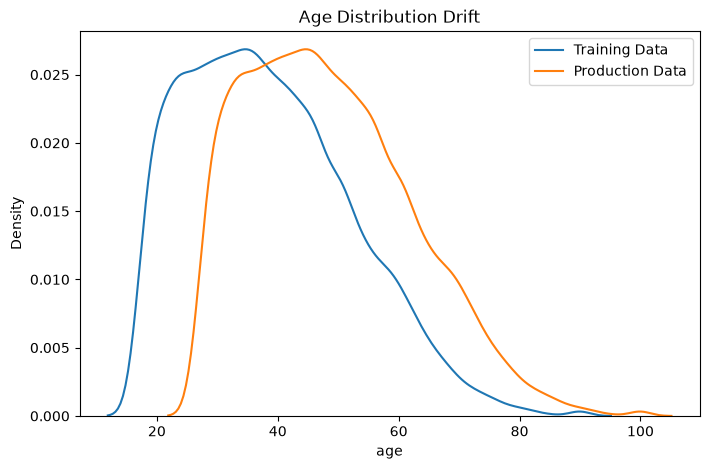

In [14]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    train["age"],
    label="Training Data"
)

sns.kdeplot(
    production["age"],
    label="Production Data"
)

plt.title("Age Distribution Drift")
plt.legend()

plt.show()

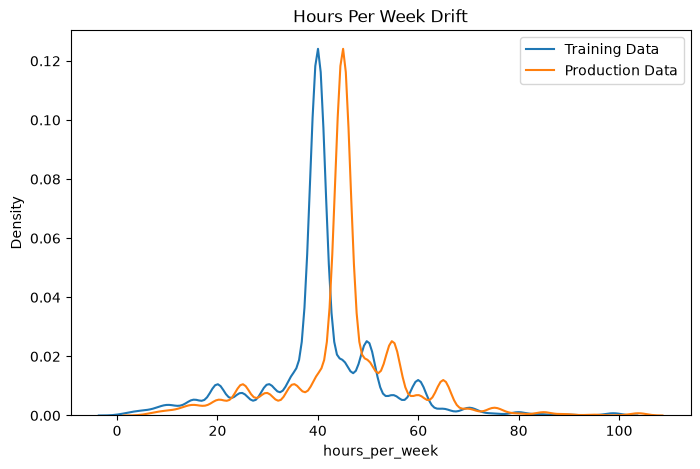

In [15]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    train["hours_per_week"],
    label="Training Data"
)

sns.kdeplot(
    production["hours_per_week"],
    label="Production Data"
)

plt.title("Hours Per Week Drift")
plt.legend()

plt.show()

In [16]:
heatmap_data = report[
    ["Feature", "Severity"]
]

heatmap_data

,Feature,Severity
0,age,26.57
1,fnlwgt,0.00
2,education_num,0.00
3,capital_gain,1.85
4,capital_loss,0.00
5,hours_per_week,49.45


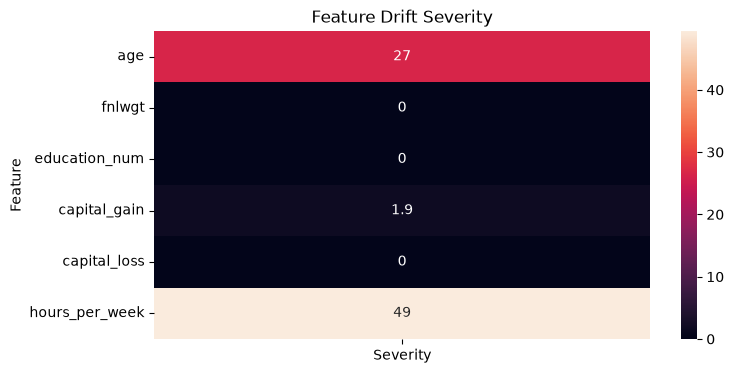

In [17]:
plt.figure(figsize=(8,4))

sns.heatmap(
    heatmap_data.set_index("Feature"),
    annot=True
)

plt.title("Feature Drift Severity")

plt.show()

In [18]:
drifted = len(
    report[
        report["Drift"] == "Yes"
    ]
)

print("Drifted Features:", drifted)

Drifted Features: 3


In [19]:
if drifted >= 2:
    print("RECOMMEND RETRAINING")
else:
    print("MODEL STABLE")

RECOMMEND RETRAINING


In [20]:
def get_level(x):
    if x < 5:
        return "Low"
    elif x < 20:
        return "Medium"
    else:
        return "High"

report["Level"] = report["Severity"].apply(get_level)

report

,Feature,KS_Statistic,P_Value,Drift,Severity,Level
0,age,0.265655,0.000000,Yes,26.57,High
1,fnlwgt,0.000000,1.000000,No,0.00,Low
2,education_num,0.000000,1.000000,No,0.00,Low
3,capital_gain,0.018519,0.000028,Yes,1.85,Low
4,capital_loss,0.000000,1.000000,No,0.00,Low
5,hours_per_week,0.494457,0.000000,Yes,49.45,High


In [21]:
drifted_features = report[
    report["Drift"] == "Yes"
]["Feature"].tolist()

print("=== DRIFT ALERT ===")
print()

for feature in drifted_features:
    print(f"Drift detected in {feature}")

print()

if len(drifted_features) >= 2:
    print("Recommendation: Retrain Model")
else:
    print("Recommendation: Continue Monitoring")

=== DRIFT ALERT ===

Drift detected in age
Drift detected in capital_gain
Drift detected in hours_per_week

Recommendation: Retrain Model


In [22]:
from sklearn.preprocessing import LabelEncoder

train_ml = train.copy()
production_ml = production.copy()

encoders = {}

for col in train_ml.select_dtypes(include="object").columns:

    le = LabelEncoder()

    train_ml[col] = le.fit_transform(
        train_ml[col].astype(str)
    )

    production_ml[col] = le.transform(
        production_ml[col].astype(str)
    )

    encoders[col] = le

print("Encoding completed")

C:\Users\Khaja\AppData\Local\Temp\ipykernel_14296\1701937784.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in train_ml.select_dtypes(include="object").columns:


Encoding completed


In [23]:
X_train = train_ml.drop("income", axis=1)
y_train = train_ml["income"]

X_prod = production_ml.drop("income", axis=1)
y_prod = production_ml["income"]

print(X_train.shape)

(32561, 14)


In [24]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

print("Model trained")

Model trained


In [25]:
from sklearn.metrics import accuracy_score

pred_train = model.predict(X_train)

acc_train = accuracy_score(
    y_train,
    pred_train
)

print("Training Accuracy:", acc_train)

Training Accuracy: 0.9999692884125181


In [26]:
pred_prod = model.predict(X_prod)

acc_prod = accuracy_score(
    y_prod,
    pred_prod
)

print("Production Accuracy:", acc_prod)

Production Accuracy: 0.8742667608488682


In [27]:
drop = (
    (acc_train - acc_prod)
    / acc_train
) * 100

print(
    f"Accuracy Drop: {drop:.2f}%"
)

Accuracy Drop: 12.57%


In [28]:
print("="*50)
print("DATA DRIFT MONITORING REPORT")
print("="*50)

print()

print(
    f"Drifted Features: {drifted}"
)

print(
    f"Training Accuracy: {acc_train:.4f}"
)

print(
    f"Production Accuracy: {acc_prod:.4f}"
)

print(
    f"Accuracy Drop: {drop:.2f}%"
)

print()

if drifted >= 2:
    print(
        "ACTION: RETRAIN MODEL"
    )
else:
    print(
        "ACTION: CONTINUE MONITORING"
    )

DATA DRIFT MONITORING REPORT

Drifted Features: 3
Training Accuracy: 1.0000
Production Accuracy: 0.8743
Accuracy Drop: 12.57%

ACTION: RETRAIN MODEL
